In [1]:
import sys
print(sys.executable)

c:\Users\sb3016\AppData\Local\Programs\Python\Python313\python.exe


Module 1: Data Loading & Schema Handling


Task 1: Load all CSV files into PySpark DataFrames


In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("COVID19Analysis").getOrCreate()

print("Spark is running:", spark.version)

Spark is running: 4.1.1


In [3]:
full_grouped = spark.read.csv("data/full_grouped.csv", header=True, inferSchema=True)
covid_complete = spark.read.csv("data/covid_19_clean_complete.csv", header=True, inferSchema=True)
country_wise = spark.read.csv("data/country_wise_latest.csv", header=True, inferSchema=True)
day_wise = spark.read.csv("data/day_wise.csv", header=True, inferSchema=True)
usa_county = spark.read.csv("data/usa_county_wise.csv", header=True, inferSchema=True)
worldometer = spark.read.csv("data/worldometer_data.csv", header=True, inferSchema=True)

print("Datasets loaded successfully")

Datasets loaded successfully


In [ ]:
datasets = {
    "full_grouped": full_grouped,
    "covid_complete": covid_complete,
    "country_wise": country_wise,
    "day_wise": day_wise,
    "usa_county": usa_county,
    "worldometer": worldometer
}

for name, df in datasets.items():
    
    print(f"Dataset: {name}")
    print(f"Row Count: {df.count()}")
    df.printSchema()

Dataset: full_grouped
Row Count: 35156
root
 |-- Date: date (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- WHO Region: string (nullable = true)

Dataset: covid_complete
Row Count: 49068
root
 |-- Province/State: string (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Lat: double (nullable = true)
 |-- Long: double (nullable = true)
 |-- Date: date (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- WHO Region: string (nullable = true)

Dataset: country_wise
Row Count: 187
root
 |-- Country/Region: string (nullable = true)
 |--

Module 2: Data Cleaning Tasks

Task 2: Handle Missing Province/State Values

In [ ]:
from pyspark.sql.functions import col, isnan, when, count

# Count nulls in every column

print("Null counts in covid_complete")

covid_complete.select([
    count(when(col(c).isNull(), c)).alias(c) 
    for c in covid_complete.columns
]).show()

Null counts in covid_complete
+--------------+--------------+---+----+----+---------+------+---------+------+----------+
|Province/State|Country/Region|Lat|Long|Date|Confirmed|Deaths|Recovered|Active|WHO Region|
+--------------+--------------+---+----+----+---------+------+---------+------+----------+
|         34404|             0|  0|   0|   0|        0|     0|        0|     0|         0|
+--------------+--------------+---+----+----+---------+------+---------+------+----------+



In [6]:
# Filter rows where Province/State is null
null_rows = covid_complete.filter(col("Province/State").isNull())

print(f"Total rows with null Province: {null_rows.count()}")
null_rows.show(5)

Total rows with null Province: 34404
+--------------+--------------+--------+---------+----------+---------+------+---------+------+--------------------+
|Province/State|Country/Region|     Lat|     Long|      Date|Confirmed|Deaths|Recovered|Active|          WHO Region|
+--------------+--------------+--------+---------+----------+---------+------+---------+------+--------------------+
|          NULL|   Afghanistan|33.93911|67.709953|2020-01-22|        0|     0|        0|     0|Eastern Mediterra...|
|          NULL|       Albania| 41.1533|  20.1683|2020-01-22|        0|     0|        0|     0|              Europe|
|          NULL|       Algeria| 28.0339|   1.6596|2020-01-22|        0|     0|        0|     0|              Africa|
|          NULL|       Andorra| 42.5063|   1.5218|2020-01-22|        0|     0|        0|     0|              Europe|
|          NULL|        Angola|-11.2027|  17.8739|2020-01-22|        0|     0|        0|     0|              Africa|
+--------------+-----------

In [7]:
# Fill null Province/State with "Unknown"
covid_complete_clean = covid_complete.fillna({"Province/State": "Unknown"})


# Verify - should now be 0
remaining_nulls = covid_complete_clean.filter(col("Province/State").isNull()).count()
print(f"Remaining nulls after fix: {remaining_nulls}")

Remaining nulls after fix: 0


Task 3: Standardize Country Names

In [8]:
from pyspark.sql.functions import col

# Get distinct country names from each dataset
print(" full_grouped countries sample ")
full_grouped.select("Country/Region").distinct().orderBy("Country/Region").show(20)

print(" country_wise countries sample ")
country_wise.select("Country/Region").distinct().orderBy("Country/Region").show(20)

print(" worldometer countries sample ")
worldometer.select("Country/Region").distinct().orderBy("Country/Region").show(20)

 full_grouped countries sample 
+-------------------+
|     Country/Region|
+-------------------+
|        Afghanistan|
|            Albania|
|            Algeria|
|            Andorra|
|             Angola|
|Antigua and Barbuda|
|          Argentina|
|            Armenia|
|          Australia|
|            Austria|
|         Azerbaijan|
|            Bahamas|
|            Bahrain|
|         Bangladesh|
|           Barbados|
|            Belarus|
|            Belgium|
|             Belize|
|              Benin|
|             Bhutan|
+-------------------+
only showing top 20 rows
 country_wise countries sample 
+-------------------+
|     Country/Region|
+-------------------+
|        Afghanistan|
|            Albania|
|            Algeria|
|            Andorra|
|             Angola|
|Antigua and Barbuda|
|          Argentina|
|            Armenia|
|          Australia|
|            Austria|
|         Azerbaijan|
|            Bahamas|
|            Bahrain|
|         Bangladesh|
|        

In [10]:
from pyspark.sql.functions import when, regexp_replace

def standardize_country(df, col_name):
    return df.withColumn(col_name,
        when(col(col_name) == "US", "United States")
        .when(col(col_name) == "USA", "United States")
        .when(col(col_name) == "Korea, South", "South Korea")
        .when(col(col_name) == "Taiwan*", "Taiwan")
        .when(col(col_name) == "Congo (Kinshasa)", "DR Congo")
        .when(col(col_name) == "Congo (Brazzaville)", "Congo")
        .otherwise(col(col_name))
    )

# Apply to all 3 datasets
full_grouped = standardize_country(full_grouped, "Country/Region")
country_wise = standardize_country(country_wise, "Country/Region")
worldometer = standardize_country(worldometer, "Country/Region")

print("standardized Country names ")

standardized Country names 


In [ ]:
# Confirm "US" no longer exists, replaced by "United States"

print("Checking full_grouped:")

full_grouped.filter(col("Country/Region") == "United States").select("Country/Region").show(3)

print("Checking for old name 'US':")
full_grouped.filter(col("Country/Region") == "US").count()

Checking full_grouped:
+--------------+
|Country/Region|
+--------------+
| United States|
| United States|
| United States|
+--------------+
only showing top 3 rows
Checking for old name 'US':


0

Task 4: Remove Duplicate Daily Records

In [13]:
print(f"Total rows in full_grouped : {full_grouped.count()}")

Total rows in full_grouped : 35156


In [15]:
from pyspark.sql.functions import col

# Count rows grouped by Country + Date

duplicates = full_grouped.groupBy("Country/Region", "Date").count().filter(col("count") > 1)

print(f" Count duplicates : {duplicates.count()}")

duplicates.show(10)

 Count duplicates : 0
+--------------+----+-----+
|Country/Region|Date|count|
+--------------+----+-----+
+--------------+----+-----+



In [16]:
# Drop duplicate rows based on Country + Date
full_grouped_clean = full_grouped.dropDuplicates(["Country/Region", "Date"])

print(f"Total rows in full_grouped_clean: {full_grouped_clean.count()}")

Total rows in full_grouped_clean: 35156


Module 3: Aggregation Tasks


Task 5: Top 10 Countries by Total Confirmed Cases

In [18]:
from pyspark.sql.functions import col

# Sort by Confirmed cases descending, 
# take top 10

top10 = country_wise.select("Country/Region", "Confirmed").orderBy(col("Confirmed").desc()).limit(10)

top10.show()

+--------------+---------+
|Country/Region|Confirmed|
+--------------+---------+
| United States|  4290259|
|        Brazil|  2442375|
|         India|  1480073|
|        Russia|   816680|
|  South Africa|   452529|
|        Mexico|   395489|
|          Peru|   389717|
|         Chile|   347923|
|United Kingdom|   301708|
|          Iran|   293606|
+--------------+---------+



In [19]:
# Convert Spark DataFrame to Pandas for plotting
top10_pd = top10.toPandas()
print(top10_pd)

   Country/Region  Confirmed
0   United States    4290259
1          Brazil    2442375
2           India    1480073
3          Russia     816680
4    South Africa     452529
5          Mexico     395489
6            Peru     389717
7           Chile     347923
8  United Kingdom     301708
9            Iran     293606


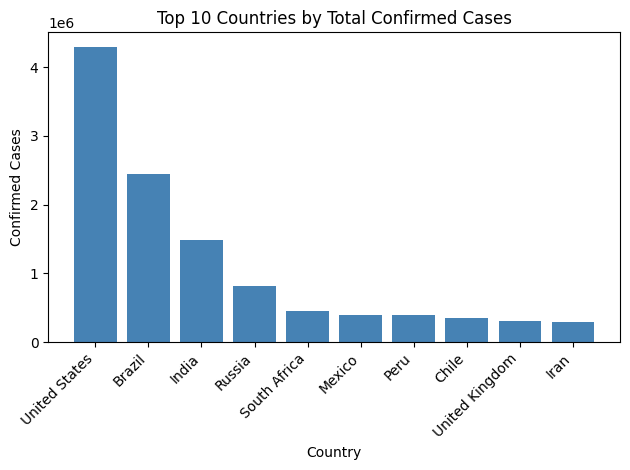

In [ ]:
import matplotlib.pyplot as plt

plt.bar(top10_pd["Country/Region"], top10_pd["Confirmed"], color="steelblue")

plt.title("Top 10 Countries by Total Confirmed Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")

plt.xticks(rotation=45, ha="right")  # horizantal alignment 
plt.tight_layout() 
plt.show()

Task 6: Top 10 Countries by Death Rate

In [33]:
from pyspark.sql.functions import col, round

death_rate = country_wise.select(
    "Country/Region",
    "Confirmed",
    "Deaths",
    round((col("Deaths") / col("Confirmed")) * 100, 2).alias("Death_Rate")
) \
.filter(col("Confirmed") > 1000) \
.orderBy(col("Death_Rate").desc()) \
.limit(10)

death_rate.show()

+--------------+---------+------+----------+
|Country/Region|Confirmed|Deaths|Death_Rate|
+--------------+---------+------+----------+
|         Yemen|     1691|   483|     28.56|
|United Kingdom|   301708| 45844|     15.19|
|       Belgium|    66428|  9822|     14.79|
|         Italy|   246286| 35112|     14.26|
|        France|   220352| 30212|     13.71|
|       Hungary|     4448|   596|      13.4|
|   Netherlands|    53413|  6160|     11.53|
|        Mexico|   395489| 44022|     11.13|
|         Spain|   272421| 28432|     10.44|
|        Canada|   116458|  8944|      7.68|
+--------------+---------+------+----------+



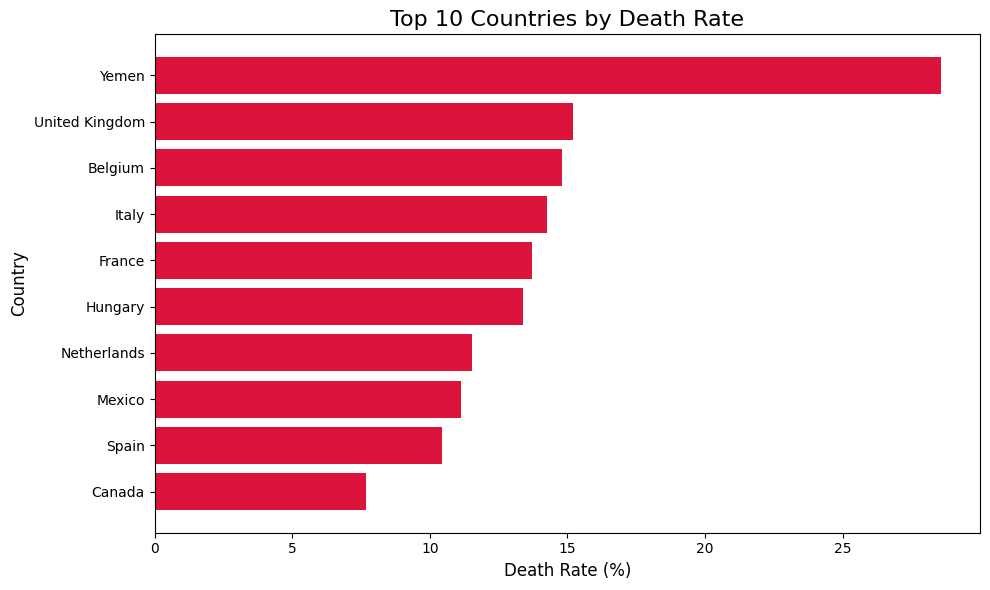

In [ ]:
import matplotlib.pyplot as plt

death_rate_pd = death_rate.toPandas()


plt.barh(death_rate_pd["Country/Region"], death_rate_pd["Death_Rate"], color="crimson")

plt.title("Top 10 Countries by Death Rate")
plt.xlabel("Death Rate (%)")
plt.ylabel("Country")

plt.gca().invert_yaxis()  # gca = get current axis, invert to have highest death rate on top

plt.tight_layout() #
plt.show()

Task 7: WHO Region-wise Total Cases

In [36]:
from pyspark.sql.functions import col, sum

# Group by WHO Region
region = full_grouped_clean.groupBy("WHO Region") \
    .agg(
        sum("Confirmed").alias("Total_Confirmed"),
        sum("Deaths").alias("Total_Deaths"),
        sum("Recovered").alias("Total_Recovered")
    ) \
    .orderBy(col("Total_Confirmed").desc())

region.show()

+--------------------+---------------+------------+---------------+
|          WHO Region|Total_Confirmed|Total_Deaths|Total_Recovered|
+--------------------+---------------+------------+---------------+
|            Americas|      402261194|    19359292|      157069444|
|              Europe|      248879793|    19271040|      123202075|
|Eastern Mediterra...|       74082892|     1924029|       48050703|
|     South-East Asia|       55118365|     1458134|       30030327|
|     Western Pacific|       26374411|      932430|       18861950|
|              Africa|       21791827|      439978|       11193730|
+--------------------+---------------+------------+---------------+



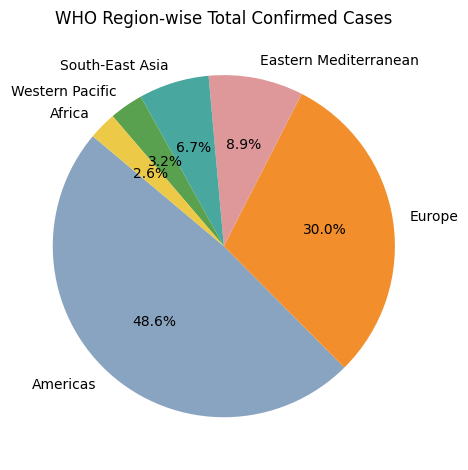

In [41]:
import matplotlib.pyplot as plt

region_pd = region.toPandas()

plt.pie(
    region_pd["Total_Confirmed"],
    labels=region_pd["WHO Region"],
    autopct="%1.1f%%", # min 1 digit before decimal,after decimal 1 digit, and % sign
    startangle=140, # start angle for better visualization
    colors=["#89a4c1","#f28e2b","#df9899","#48a79f","#59a14f","#edc948"]
)

plt.title("WHO Region-wise Total Confirmed Cases")
plt.tight_layout()
plt.show()

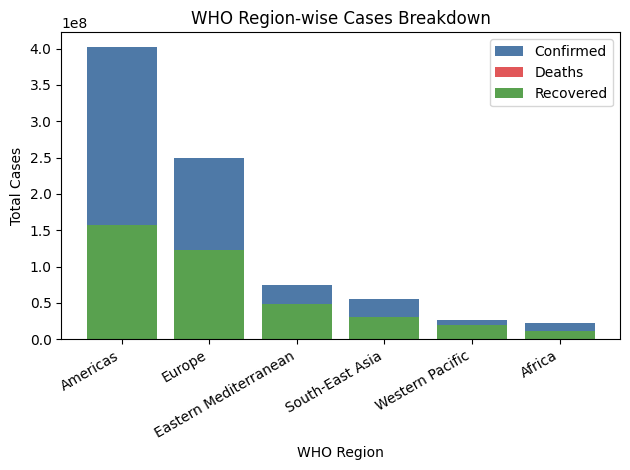

In [46]:
import numpy as np

x = region_pd["WHO Region"]
width = 0.5

fig, ax = plt.subplots() # create figure and axis for plotting
ax.bar(x, region_pd["Total_Confirmed"], label="Confirmed", color="#4e79a7")
ax.bar(x, region_pd["Total_Deaths"], label="Deaths", color="#e15759")
ax.bar(x, region_pd["Total_Recovered"], label="Recovered", color="#59a14f")

ax.set_title("WHO Region-wise Cases Breakdown")
ax.set_xlabel("WHO Region")
ax.set_ylabel("Total Cases")


ax.legend() # show legend to differentiate bars 

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Module 4: Time-Series Analysis


Task 8: Daily Global New Cases Trend

In [48]:
day_wise.show(5)
day_wise.printSchema()

+----------+---------+------+---------+------+---------+----------+-------------+------------------+---------------------+----------------------+----------------+
|      Date|Confirmed|Deaths|Recovered|Active|New cases|New deaths|New recovered|Deaths / 100 Cases|Recovered / 100 Cases|Deaths / 100 Recovered|No. of countries|
+----------+---------+------+---------+------+---------+----------+-------------+------------------+---------------------+----------------------+----------------+
|2020-01-22|      555|    17|       28|   510|        0|         0|            0|              3.06|                 5.05|                 60.71|               6|
|2020-01-23|      654|    18|       30|   606|       99|         1|            2|              2.75|                 4.59|                  60.0|               8|
|2020-01-24|      941|    26|       36|   879|      287|         8|            6|              2.76|                 3.83|                 72.22|               9|
|2020-01-25|     1434|

In [60]:
from pyspark.sql.functions import col, to_date

# Select and sort by date

daily_cases = day_wise.select(
    to_date(col("Date"), "yyyy-MM-dd").alias("Date"),
    col("New cases").alias("New_Cases")
) \
.orderBy("Date")

daily_cases.show(10)

+----------+---------+
|      Date|New_Cases|
+----------+---------+
|2020-01-22|        0|
|2020-01-23|       99|
|2020-01-24|      287|
|2020-01-25|      493|
|2020-01-26|      684|
|2020-01-27|      809|
|2020-01-28|     2651|
|2020-01-29|      588|
|2020-01-30|     2068|
|2020-01-31|     1693|
+----------+---------+
only showing top 10 rows


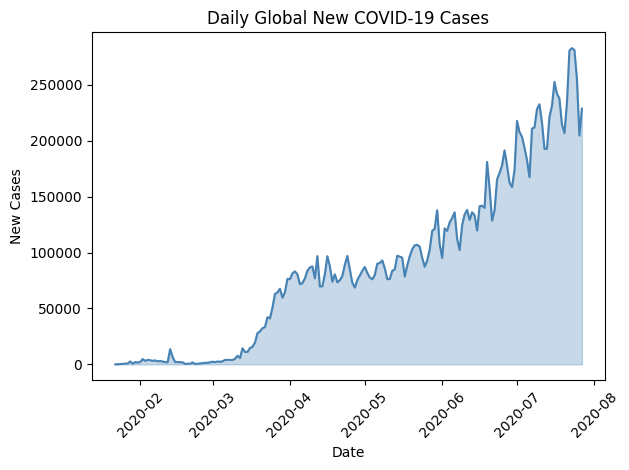

In [64]:
import matplotlib.pyplot as plt

daily_pd = daily_cases.toPandas()

plt.figure()
plt.plot(daily_pd["Date"], daily_pd["New_Cases"], color="steelblue")
plt.fill_between(daily_pd["Date"], daily_pd["New_Cases"], alpha=0.3, color="steelblue")  # alpha -->  color transparency

plt.title("Daily Global New COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Task 9: Daily Global Death Growth Trend

In [66]:
from pyspark.sql.functions import col, lag, round, to_date, when
from pyspark.sql.window import Window


window_spec = Window.orderBy("Date")

# get data

daily_deaths = day_wise.select(
    to_date(col("Date"), "yyyy-MM-dd").alias("Date"),
    col("New deaths").alias("New_Deaths")
).orderBy("Date")


# lag --> prev days deaths

daily_deaths = daily_deaths.withColumn(
    "Prev_Deaths", lag("New_Deaths", 1).over(window_spec)
)

# death growth %

daily_deaths = daily_deaths.withColumn(
    "Death_Growth_Pct",
    when(
        (col("Prev_Deaths").isNull()) | (col("Prev_Deaths") == 0), None
    ).otherwise(
        round((col("New_Deaths") - col("Prev_Deaths")) / col("Prev_Deaths") * 100, 2)
    )
)

daily_deaths.show(10)

+----------+----------+-----------+----------------+
|      Date|New_Deaths|Prev_Deaths|Death_Growth_Pct|
+----------+----------+-----------+----------------+
|2020-01-22|         0|       NULL|            NULL|
|2020-01-23|         1|          0|            NULL|
|2020-01-24|         8|          1|           700.0|
|2020-01-25|        16|          8|           100.0|
|2020-01-26|        14|         16|           -12.5|
|2020-01-27|        26|         14|           85.71|
|2020-01-28|        49|         26|           88.46|
|2020-01-29|         2|         49|          -95.92|
|2020-01-30|        38|          2|          1800.0|
|2020-01-31|        42|         38|           10.53|
+----------+----------+-----------+----------------+
only showing top 10 rows


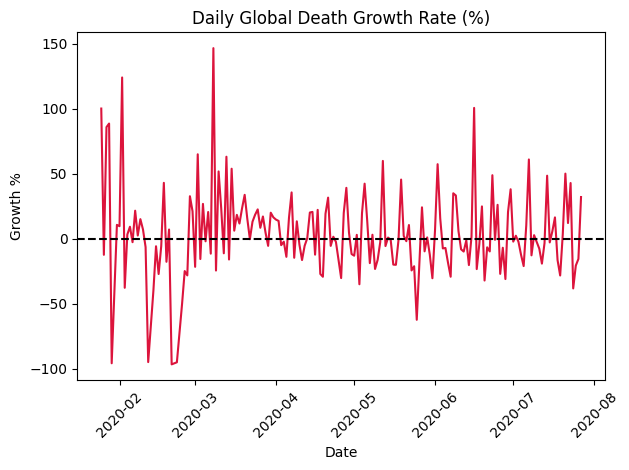

In [ ]:
import matplotlib.pyplot as plt

deaths_pd = daily_deaths.toPandas()

# Remove nulls   & extreme outliers for clean chart

deaths_pd = deaths_pd.dropna(subset=["Death_Growth_Pct"])
deaths_pd = deaths_pd[deaths_pd["Death_Growth_Pct"].between(-100, 200)]

plt.figure()
plt.plot(deaths_pd["Date"], deaths_pd["Death_Growth_Pct"], color="green")
plt.axhline(y=0, color="black", linestyle="--")  # axis horizantal line 

plt.title("Daily Global Death Growth Rate (%)")
plt.xlabel("Date")
plt.ylabel("Growth %")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
# Use Python's built-in round by calling it directly
print("Max Death Growth %:", deaths_pd["Death_Growth_Pct"].max())
print("Min Death Growth %:", deaths_pd["Death_Growth_Pct"].min())
print("Average Death Growth %:", deaths_pd["Death_Growth_Pct"].mean().__round__(2))

Max Death Growth %: 146.46
Min Death Growth %: -96.75
Average Death Growth %: 4.04


Task 10: Monthly COVID Case Growth

In [40]:
from pyspark.sql.functions import month, year, sum, col, to_date

# Convert Date column and extract month/year
monthly_cases = full_grouped_clean.withColumn(
    "Date", to_date(col("Date"), "yyyy-MM-dd")
) \
.withColumn("Year", year(col("Date"))) \
.withColumn("Month", month(col("Date")))

# Group by Year + Month
monthly_summary = monthly_cases.groupBy("Year", "Month") \
    .agg(sum("Confirmed").alias("Total_Confirmed")) \
    .orderBy("Year", "Month")

monthly_summary.show(20)

+----+-----+---------------+
|Year|Month|Total_Confirmed|
+----+-----+---------------+
|2020|    1|          38534|
|2020|    2|        1663437|
|2020|    3|        9002815|
|2020|    4|       63391662|
|2020|    5|      144990399|
|2020|    6|      246525787|
|2020|    7|      362895848|
+----+-----+---------------+



In [41]:
from pyspark.sql.functions import concat, lit, lpad

# Create a readable label like "2020-01"
monthly_summary = monthly_summary.withColumn(
    "Month_Year",
    concat(col("Year"), lit("-"), lpad(col("Month"), 2, "0"))
)

monthly_summary.show(20)

+----+-----+---------------+----------+
|Year|Month|Total_Confirmed|Month_Year|
+----+-----+---------------+----------+
|2020|    1|          38534|   2020-01|
|2020|    2|        1663437|   2020-02|
|2020|    3|        9002815|   2020-03|
|2020|    4|       63391662|   2020-04|
|2020|    5|      144990399|   2020-05|
|2020|    6|      246525787|   2020-06|
|2020|    7|      362895848|   2020-07|
+----+-----+---------------+----------+



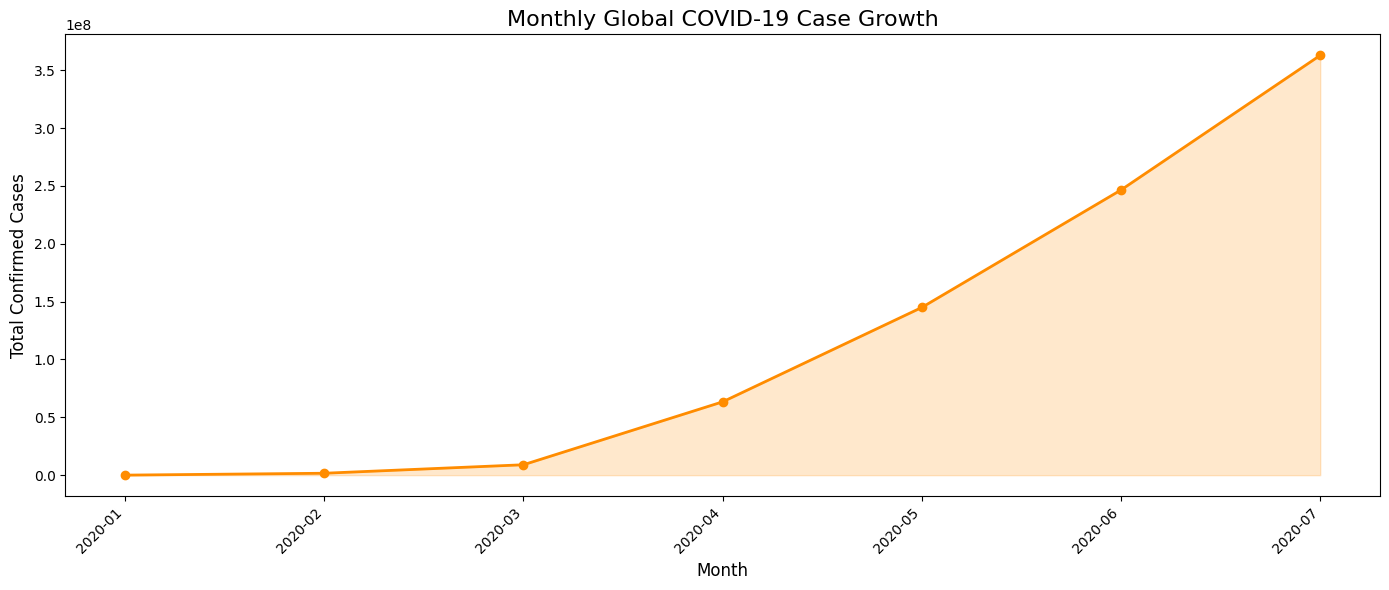

In [42]:
import matplotlib.pyplot as plt

monthly_pd = monthly_summary.toPandas()
monthly_pd = monthly_pd.sort_values(["Year", "Month"])

plt.figure(figsize=(14, 6))
plt.plot(monthly_pd["Month_Year"], monthly_pd["Total_Confirmed"], 
         marker="o", color="darkorange", linewidth=2)
plt.fill_between(monthly_pd["Month_Year"], monthly_pd["Total_Confirmed"], 
                 alpha=0.2, color="darkorange")
plt.title("Monthly Global COVID-19 Case Growth", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Confirmed Cases", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Task 11: Top 5 Most Affected Countries Per WHO Region